In [17]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

In [18]:
N = 20
Zmin = 0
Zmax = 10
Z = np.sort(np.random.uniform(Zmin,Zmax,N))

In [19]:
a = 2
b = 1
sd = 0.5
Tobs = a + b*Z + np.random.normal(0,sd,N)

In [20]:
Tobs[N-1] = 1

In [21]:
w = np.eye(N)
w[N-1][N-1] = 0.1

G = np.zeros((N, 2))
for i in range(N) :
    G[i][0] = 1
    G[i][1] = Z[i]

d = np.reshape(Tobs,(N,1))

In [22]:
m = np.mat(inv(np.mat(G.transpose())* np.mat(w)* np.mat(G))) * np.mat(G.transpose())*np.mat(w)*np.mat(d)
m = m.tolist()
b0 = m[0][0]
b1 = m[1][0]

inv_weighted = []
for i in range(len(Z)):
    inv_weighted.append(b0+b1*Z[i])

In [23]:
m2 = np.mat(inv(np.mat(G.transpose())* np.mat(G)))*np.mat(G.transpose())*np.mat(d)
m2 = m2.tolist()
a0 = m2[0][0]
a1 = m2[1][0]

inv_without_weighted = []
for i in range(len(Z)) :
    inv_without_weighted.append(a0+a1*Z[i])

Misfit with weighted : [[12.65063285]]
Misfit without weighted ; [[103.93450362]]


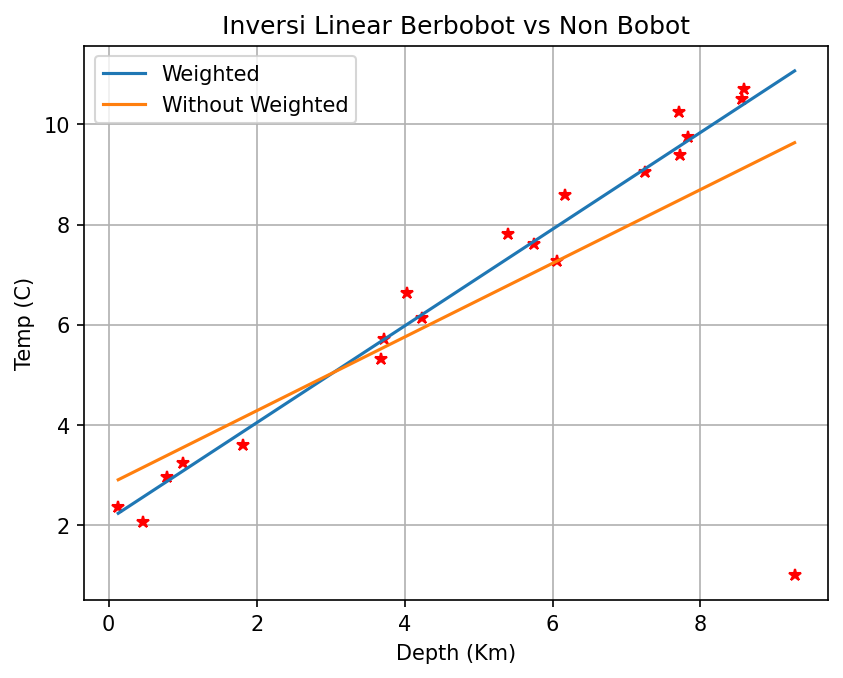

In [24]:
E = np.mat(np.transpose(np.reshape(inv_weighted,(N,1))-d))*np.mat(w)*np.mat(np.reshape(inv_weighted,(N,1))-d)
E1 = np.mat(np.transpose(np.reshape(inv_weighted,(N,1))-d))*np.mat(np.reshape(inv_weighted,(N,1))-d)

print('Misfit with weighted :', E)
print('Misfit without weighted ;', E1)
plt.plot(Z, Tobs, '*r')
plt.plot(Z, inv_weighted, label='Weighted')
plt.plot(Z, inv_without_weighted, label='Without Weighted')
plt.title('Inversi Linear Berbobot vs Non Bobot')
plt.ylabel('Temp (C)')
plt.xlabel('Depth (Km)')
plt.legend()
plt.grid()
plt.show()
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150